In [30]:
import keras
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [47]:
import matplotlib.pyplot as plt


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import os
def plot_imgs(directory, top=10):
    all_item_dirs = os.listdir(directory)
    item_files = [os.path.join(directory, file) for file in all_item_dirs][:5]

    plt.figure(figsize=(20, 20))

    for i, img_path in enumerate(item_files):
        plt.subplot(10, 10, i+1)

        img = plt.imread(img_path)
        plt.tight_layout()
        plt.imshow(img, cmap='gray')

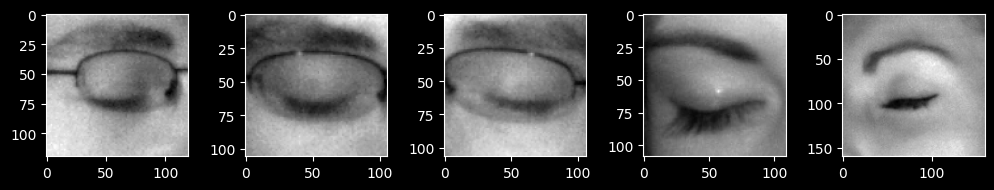

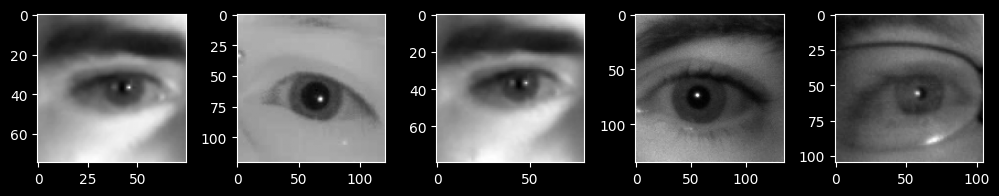

In [34]:
data_path = '/content/drive/MyDrive/dataset/train'

directories = ['/Closed_Eyes', '/Open_Eyes']

for j in directories:
    plot_imgs(data_path+j)

In [35]:
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6,1.4],
    validation_split = 0.1
)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [36]:
train_data_path = data_path
test_data_path = '/content/drive/MyDrive/dataset/test'

train_set = train_datagen.flow_from_directory(train_data_path, target_size = (64,64),
                                              batch_size = batch_size,
                                              color_mode = 'grayscale',
                                              class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_data_path, target_size = (64,64),
                                              batch_size = batch_size,
                                              color_mode = 'grayscale',
                                              class_mode = 'categorical')

Found 3400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


In [37]:
import keras
from keras.regularizers import l2

classes = 2

model = Sequential()
model.add(Conv2D(32, (3,3), padding = 'same', input_shape = (64,64,1), activation = 'relu', kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding = 'same', activation = 'relu', kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,(3,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(64, activation = 'relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

model.add(Dense(classes, activation = 'softmax'))

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,154 (2.35 MB)

 Trainable params: 617,154 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

None


In [38]:
model.compile(loss = 'categorical_crossentropy',optimizer = 'adam' , metrics = ['accuracy'])

In [39]:
from tqdm.keras import TqdmCallback
from keras.callbacks import EarlyStopping

model_path="yawn_detection.h5"

checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', verbose=1,
                              save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

callbacks_list = [checkpoint, TqdmCallback(), early_stopping]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [40]:
num_epochs = 10
training_steps=train_set.n//train_set.batch_size
validation_steps =test_set.n//test_set.batch_size

In [41]:
history = model.fit(
    train_set,
    epochs=num_epochs,
    validation_data=test_set,
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5955 - loss: 0.8369
Epoch 1: val_accuracy improved from -inf to 0.97167, saving model to yawn_detection.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 190ms/step - accuracy: 0.5962 - loss: 0.8359 - val_accuracy: 0.9717 - val_loss: 0.2260
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8112 - loss: 0.4884
Epoch 2: val_accuracy improved from 0.97167 to 0.98833, saving model to yawn_detection.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.8115 - loss: 0.4881 - val_accuracy: 0.9883 - val_loss: 0.1158
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8721 - loss: 0.3853
Epoch 3: val_accuracy improved from 0.98833 to 0.99333, saving model to yawn_detection.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.8722 - loss: 0.3852 - val_accuracy: 0.9933 - val_loss: 0.1154
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9075 - loss: 0.3246
Epoch 4: val_accuracy improved from 0.99333 to 0.99500, saving model to yawn_detection.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.9075 - loss: 0.3245 - val_accuracy: 0.9950 - val_loss: 0.1041
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8988 - loss: 0.3338
Epoch 5: val_accuracy did not improve from 0.99500
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.8989 - loss: 0.3337 - val_accuracy: 0.9933 - val_loss: 0.0913
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9128 - loss: 0.2934
Epoch 6: val_accuracy did not improve from 0.99500
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.9129 - loss: 0.2933 - val_accuracy: 0.9900 - val_loss: 0.0980
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9086 - loss: 0.2905
Epoch 7: val_accuracy did not improve from 0.99500
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.9086 - loss: 0.2905 - val_accuracy: 0.9883 - val_loss: 0.1095
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9238 - loss: 0.2952
Epoch 8: val_ac

107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.9238 - loss: 0.2949 - val_accuracy: 1.0000 - val_loss: 0.0862
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9353 - loss: 0.2669
Epoch 9: val_accuracy did not improve from 1.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.9353 - loss: 0.2668 - val_accuracy: 1.0000 - val_loss: 0.0871
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9342 - loss: 0.2499
Epoch 10: val_accuracy did not improve from 1.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.9342 - loss: 0.2498 - val_accuracy: 1.0000 - val_loss: 0.0831


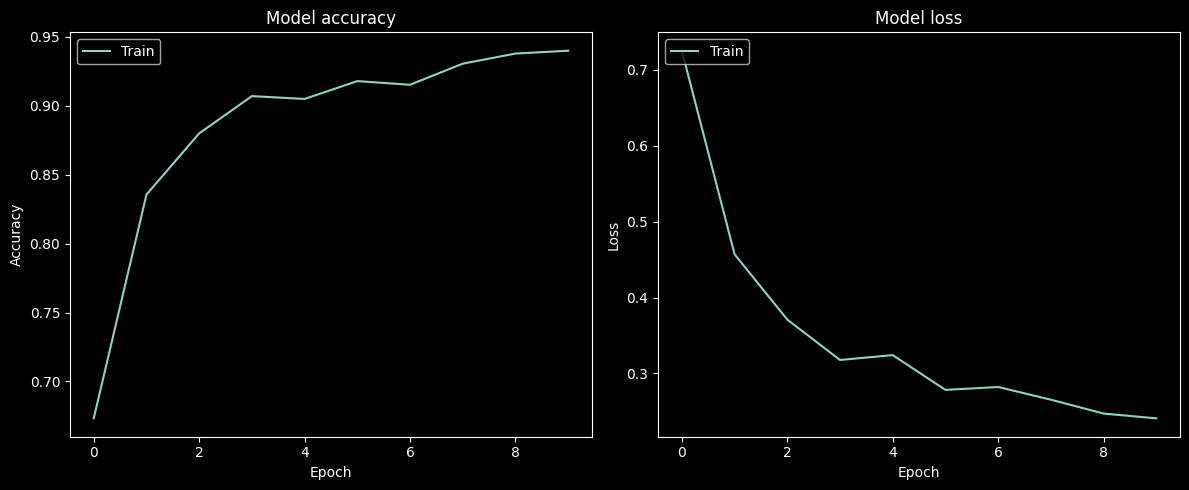

In [49]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.tight_layout()
plt.savefig('training_metrics.png') # Save the figure as a PNG
plt.show()

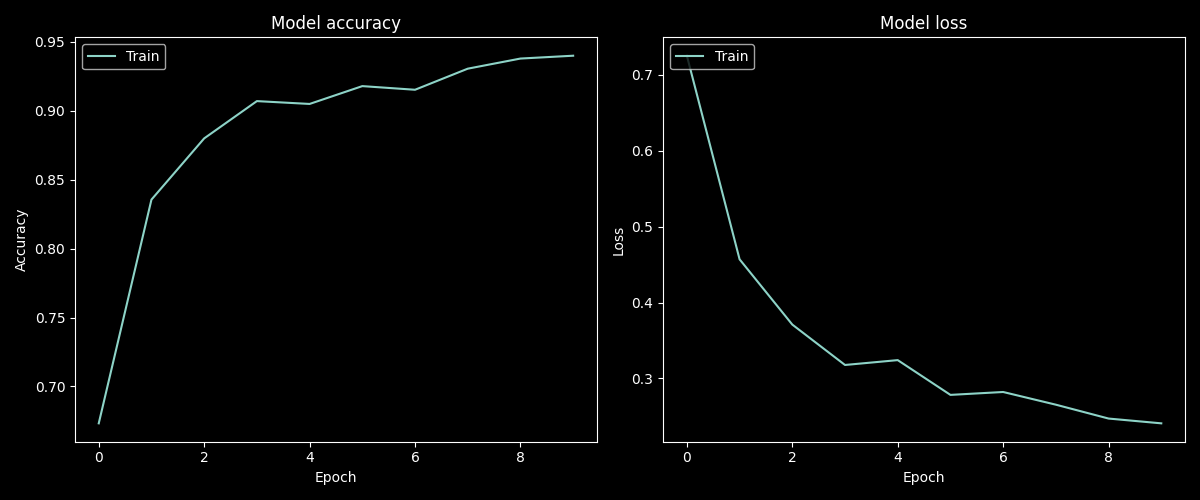

In [50]:
from IPython.display import Image
Image('training_metrics.png')